# Test: ParticleSpringForceDiffusionField generator

Visualize 3D particles with spring forces + chemotaxis from a diffusion-decay field with cell sources.

PDE: dc/dt = D * laplacian(c) - lambda * c + alpha * sum_i delta(x - x_i)

Three panels per frame:
1. 3D scatter of particle positions
2. Top-down (xy) projection of particles colored by local field value
3. Top-down field slice (z=0.5) with particles overlaid

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('../src'))

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import trange
from IPython.display import Video, display
import matplotlib.animation as animation

from cell_gnn.cell_state import CellState
from cell_gnn.utils import edges_radius_blockwise, choose_boundary_values
from cell_gnn.generators.particle_spring_force_diffusion_field import (
    ParticleSpringForceDiffusionField,
)
from cell_gnn.integrators import rk4_step

## Parameters

In [2]:
device = 'cpu'

# Parameters from config/misc/dicty_spring_force_rk4_diffusion_field_v1.yaml
n_cells = 1000
dimension = 3
n_frames = 8000
delta_t = 0.002
max_radius = 0.075
min_radius = 0.0
noise_level = 0.0

# spring force params: [k_rep, r0, kadh, r_on, delta, mu_f]
cell_params = torch.tensor([50.0, 0.05, 50.0, 0.07, 0.001, 0.033], device=device)

# diffusion field params
grid_resolution = 100

field_params = {
    'diffusion_coeff': 0.01,     # D
    'lambda_decay': 0.1,         # lambda
    'grid_resolution': grid_resolution,
    'source_strength': 20.0,      # alpha
    'center_0': torch.tensor([
        [0.50, 0.50, 0.50],
    ], device=device),
    'amplitude': 0.0,
    'sigma': 0.1,
    'mu_chem': 0.1,
    'delta_t': delta_t,
    'periodic': True,
}

# boundary conditions
bc_pos, bc_dpos = choose_boundary_values('periodic')

# Steady-state estimate: alpha * n_cells * dt / (lambda * res^3)
ss_est = field_params['source_strength'] * n_cells * delta_t / (field_params['lambda_decay'] * grid_resolution**3)
print(f"D = {field_params['diffusion_coeff']}, lambda = {field_params['lambda_decay']}")
print(f"source_strength = {field_params['source_strength']}")
print(f"grid_resolution = {grid_resolution}^3 = {grid_resolution**3} points")
print(f"mu_chem = {field_params['mu_chem']}")
print(f"max_radius = {max_radius}, cell_params = {cell_params.tolist()}")
print(f"Estimated steady-state per-cell contribution: {ss_est:.6f}")

D = 0.01, lambda = 0.1
source_strength = 20.0
grid_resolution = 100^3 = 1000000 points
mu_chem = 0.1
max_radius = 0.075, cell_params = [50.0, 0.05000000074505806, 50.0, 0.07000000029802322, 0.0010000000474974513, 0.032999999821186066]
Estimated steady-state per-cell contribution: 0.000400


## Initialize cells & model

In [3]:
torch.manual_seed(42)

# random initial positions in [0,1]^3
pos = torch.rand(n_cells, dimension, device=device)
vel = torch.zeros(n_cells, dimension, device=device)

x = CellState(
    index=torch.arange(n_cells, device=device),
    pos=pos,
    vel=vel,
    cell_type=torch.zeros(n_cells, dtype=torch.long, device=device),
    field=torch.ones(n_cells, 1, device=device),
)

model = ParticleSpringForceDiffusionField(
    aggr_type='add',
    p=cell_params,
    bc_dpos=bc_dpos,
    dimension=dimension,
    noise_model_level=noise_level,
    field_params=field_params,
)

print(f'Cells: {n_cells}, Frames: {n_frames}, dt: {delta_t}')

Cells: 1000, Frames: 8000, dt: 0.002


In [4]:
import types

source_fraction = 0.5
pulse_period = 500
pulse_duty = 0.5

torch.manual_seed(123)
n_src = max(1, int(round(source_fraction * n_cells)))
perm = torch.randperm(n_cells, device=device)
source_mask = torch.zeros(n_cells, dtype=torch.bool, device=device)
source_mask[perm[:n_src]] = True
source_phase = torch.rand(n_cells, device=device)

print(f"sources: {n_src}/{n_cells}, period={pulse_period} steps, duty={pulse_duty}")


def _deposit_weighted(pos, strength, resolution, dimension, dev):
    """Per-particle weighted trilinear/bilinear deposit onto a periodic grid."""
    grid_shape = [resolution] * dimension
    S = torch.zeros(grid_shape, device=dev)
    scaled = pos * resolution
    idx0 = scaled.long() % resolution
    idx1 = (idx0 + 1) % resolution
    frac = scaled - scaled.floor()

    if dimension == 3:
        ix0, iy0, iz0 = idx0[:, 0], idx0[:, 1], idx0[:, 2]
        ix1, iy1, iz1 = idx1[:, 0], idx1[:, 1], idx1[:, 2]
        fx, fy, fz = frac[:, 0], frac[:, 1], frac[:, 2]
        weights = [
            (iz0, iy0, ix0, (1 - fx) * (1 - fy) * (1 - fz)),
            (iz0, iy0, ix1, fx       * (1 - fy) * (1 - fz)),
            (iz0, iy1, ix0, (1 - fx) * fy       * (1 - fz)),
            (iz0, iy1, ix1, fx       * fy       * (1 - fz)),
            (iz1, iy0, ix0, (1 - fx) * (1 - fy) * fz),
            (iz1, iy0, ix1, fx       * (1 - fy) * fz),
            (iz1, iy1, ix0, (1 - fx) * fy       * fz),
            (iz1, iy1, ix1, fx       * fy       * fz),
        ]
        for iz, iy, ix, w in weights:
            S.index_put_((iz, iy, ix), strength * w, accumulate=True)
    else:
        ix0, iy0 = idx0[:, 0], idx0[:, 1]
        ix1, iy1 = idx1[:, 0], idx1[:, 1]
        fx, fy = frac[:, 0], frac[:, 1]
        weights = [
            (iy0, ix0, (1 - fx) * (1 - fy)),
            (iy0, ix1, fx       * (1 - fy)),
            (iy1, ix0, (1 - fx) * fy),
            (iy1, ix1, fx       * fy),
        ]
        for iy, ix, w in weights:
            S.index_put_((iy, ix), strength * w, accumulate=True)
    return S


def _patched_advance_field(self, pos, n_steps=1):
    dim = self.dimension
    res = self.field_params['grid_resolution']
    dt = self.field_params['delta_t']
    alpha = self.field_params.get('source_strength', 0.0)
    s = [res] * dim

    sigma = max(pulse_duty, 1e-3) / 2.0
    gain = 1.0 / max(pulse_duty, 1e-3)

    for i in range(n_steps):
        current_step = self._last_step + 1 + i
        if alpha > 0:
            phase = (current_step / float(pulse_period) + source_phase) % 1.0
            d = torch.minimum(phase, 1.0 - phase)
            pulse = torch.exp(-0.5 * (d / sigma) ** 2) * source_mask.float()
            active = pulse > 1e-4
            if active.any():
                strength = alpha * dt * gain * pulse[active]
                src = _deposit_weighted(pos[active], strength, res, dim, pos.device)
                self._field_grid = self._field_grid + src

        C_hat = torch.fft.rfftn(self._field_grid, s=s)
        C_hat = C_hat * self._decay
        self._field_grid = torch.fft.irfftn(C_hat, s=s)

    C_hat = torch.fft.rfftn(self._field_grid, s=s)
    return C_hat


model._advance_field = types.MethodType(_patched_advance_field, model)
print("patched model._advance_field with pulsed 20% sources")


sources: 500/1000, period=500 steps, duty=0.5
patched model._advance_field with pulsed 20% sources


In [5]:
# --- Saturating log chemotactic force (Weber–Fechner) ---
#   F_chem = mu_chem * log(1 + |grad c| / g0) * (grad c / |grad c|)
#
# Strategy: run a short warm-up so the field has structure, measure the
# per-particle pair-force magnitude and |grad c|, then pick g0 so the
# saturating chem force magnitude matches the pair-force magnitude.

from cell_gnn.generators.particle_spring_force_diffusion_field import (
    spectral_gradient, interp_periodic,
)
from torch_geometric.utils import remove_self_loops

# --- 1. Warm-up: run the PDE for a few hundred steps so the field isn't empty
from copy import deepcopy

warmup_steps = 500
x_probe = deepcopy(x)
for it in range(warmup_steps):
    def _deriv(s, _it=it):
        ei = edges_radius_blockwise(s.pos, bc_dpos, min_radius, max_radius, block=2048)
        return model(s, ei, k=_it)
    x_probe, _ = rk4_step(x_probe, _deriv, delta_t, 'first_derivative', bc_pos)

# --- 2. Measure pair force magnitude (by zeroing mu_chem temporarily)
ei = edges_radius_blockwise(x_probe.pos, bc_dpos, min_radius, max_radius, block=2048)
ei_nosl = remove_self_loops(ei)[0]

# pair force only: call message/aggregate directly
from cell_gnn.generators.particle_spring_force_diffusion_field import scatter_aggregate
p_expand = model.p.unsqueeze(0) if model.p.dim() == 1 else model.p
params_per_cell = p_expand[x_probe.cell_type.cpu().numpy(), :]
src_, dst_ = ei_nosl[1], ei_nosl[0]
msg = model.message(x_probe.pos[dst_], x_probe.pos[src_], params_per_cell[dst_])
pair_force = scatter_aggregate(msg, dst_, x_probe.n_cells, model.aggr_type)

# gradient of field at particles
res = field_params['grid_resolution']
s_shape = [res] * dimension
C_hat = torch.fft.rfftn(model._field_grid, s=s_shape)
grad_grid = spectral_gradient(C_hat, res, dimension, x_probe.pos.device)
grad_c = interp_periodic(grad_grid, x_probe.pos, res)  # (N, dim)

pair_mag = pair_force.norm(dim=1)
grad_mag = grad_c.norm(dim=1)

print(f"pair force  |F_pair|   -> median {pair_mag.median():.4e}, mean {pair_mag.mean():.4e}, max {pair_mag.max():.4e}")
print(f"field grad  |grad c|   -> median {grad_mag.median():.4e}, mean {grad_mag.mean():.4e}, max {grad_mag.max():.4e}")
print(f"current chem force |mu_chem * grad c| -> median {(field_params['mu_chem']*grad_mag).median():.4e}")

# --- 3. Pick g0 so saturating chem force ≈ pair force magnitude
#   mu_chem * log(1 + |grad c|/g0) = |F_pair|  (at median)
target = pair_mag.median().item()
g_med = grad_mag.median().item()
mu_chem = field_params['mu_chem']

# solve: mu_chem * log(1 + g_med/g0) = target  =>  g0 = g_med / (exp(target/mu_chem) - 1)
ratio = target / mu_chem
g0 = g_med / (np.exp(ratio) - 1) if ratio > 1e-8 else g_med

print(f"\nChosen saturation scale g0 = {g0:.4e}")
print(f"Check: mu_chem*log(1+g_med/g0) = {mu_chem*np.log(1+g_med/g0):.4e}  (target pair = {target:.4e})")

# --- 4. Patch model.forward to use saturating log chem force
_orig_forward = model.forward

def _forward_sat(self, state, edge_index, has_field=False, k=0):
    edge_index = remove_self_loops(edge_index)[0]
    p = self.p.unsqueeze(0) if self.p.dim() == 1 else self.p
    parameters = p[state.cell_type.cpu().numpy(), :]

    src, dst = edge_index[1], edge_index[0]
    messages = self.message(state.pos[dst], state.pos[src], parameters[dst])
    d_pos = scatter_aggregate(messages, dst, state.n_cells, self.aggr_type)

    device = state.pos.device
    for key in ('center_0',):
        v = self.field_params.get(key)
        if torch.is_tensor(v) and v.device != device:
            self.field_params[key] = v.to(device)
    if self._field_grid is None:
        self._init_grid(device)

    steps = k - self._last_step
    if steps > 0:
        C_hat = self._advance_field(state.pos, n_steps=steps)
    else:
        s_ = [self.field_params['grid_resolution']] * self.dimension
        C_hat = torch.fft.rfftn(self._field_grid, s=s_)
    self._last_step = k

    res_ = self.field_params['grid_resolution']
    grad_grid_ = spectral_gradient(C_hat, res_, self.dimension, device)
    field_value = interp_periodic(self._field_grid, state.pos, res_)
    field_gradient = interp_periodic(grad_grid_, state.pos, res_)

    # Saturating log chemotaxis: mu_chem * log(1 + |g|/g0) * g_hat
    g_norm = field_gradient.norm(dim=1, keepdim=True).clamp_min(1e-12)
    g_hat = field_gradient / g_norm
    chem = self.field_params['mu_chem'] * torch.log1p(g_norm / self._chem_g0) * g_hat
    d_pos = d_pos + chem

    state.field = field_value.unsqueeze(-1)
    self.last_clean = d_pos.clone()
    if self.noise_model_level > 0:
        noise = self.noise_model_level * torch.randn_like(d_pos)
        self.last_noise = noise
        d_pos = d_pos + noise
    return d_pos

model._chem_g0 = g0
model.forward = types.MethodType(_forward_sat, model)
print("\npatched model.forward with saturating-log chemotaxis")


pair force  |F_pair|   -> median 5.4716e-03, mean 7.7154e-03, max 5.0778e-02
field grad  |grad c|   -> median 6.5168e-02, mean 8.2377e-02, max 3.3963e-01
current chem force |mu_chem * grad c| -> median 6.5168e-03

Chosen saturation scale g0 = 1.1587e+00
Check: mu_chem*log(1+g_med/g0) = 5.4716e-03  (target pair = 5.4716e-03)

patched model.forward with saturating-log chemotaxis


## Run simulation

In [6]:
# store snapshots for video
save_every = 10
pos_history = []
field_history = []       # per-particle field value at each snapshot
field_grid_history = []  # full z=0.5 grid slice at each snapshot
time_history = []

for it in trange(n_frames, ncols=100, desc='simulating'):
    # RK4 step (this advances the PDE internally)
    def _deriv_fn(s, _it=it):
        ei = edges_radius_blockwise(s.pos, bc_dpos, min_radius, max_radius, block=2048)
        return model(s, ei, k=_it)

    x, _ = rk4_step(x, _deriv_fn, delta_t, 'first_derivative', bc_pos)

    # save snapshot
    if it % save_every == 0:
        t = it * delta_t
        pos_history.append(x.pos.clone().detach().numpy())
        field_history.append(x.field.clone().detach().squeeze().numpy())
        time_history.append(t)
        # grab z=0.5 slice from the internal grid
        grid = model._field_grid.detach().cpu().numpy()
        z_mid = grid_resolution // 2
        field_grid_history.append(grid[z_mid, :, :].copy())

print(f'Saved {len(pos_history)} snapshots')

simulating: 100%|███████████████████████████████████████████████| 8000/8000 [07:34<00:00, 17.62it/s]

Saved 800 snapshots


In [7]:
pos_history = np.array(pos_history)
field_history = np.array(field_history)
field_grid_history = np.array(field_grid_history)
time_history = np.array(time_history)

n_snapshots = len(time_history)
print(f'{n_snapshots} frames, time range [{time_history[0]:.3f}, {time_history[-1]:.3f}]')
print(f'Field grid range over all snapshots: [{field_grid_history.min():.4f}, {field_grid_history.max():.4f}]')

800 frames, time range [0.000, 15.980]
Field grid range over all snapshots: [0.0055, 0.1785]


## Preview: field evolution (z=0.5 slices)

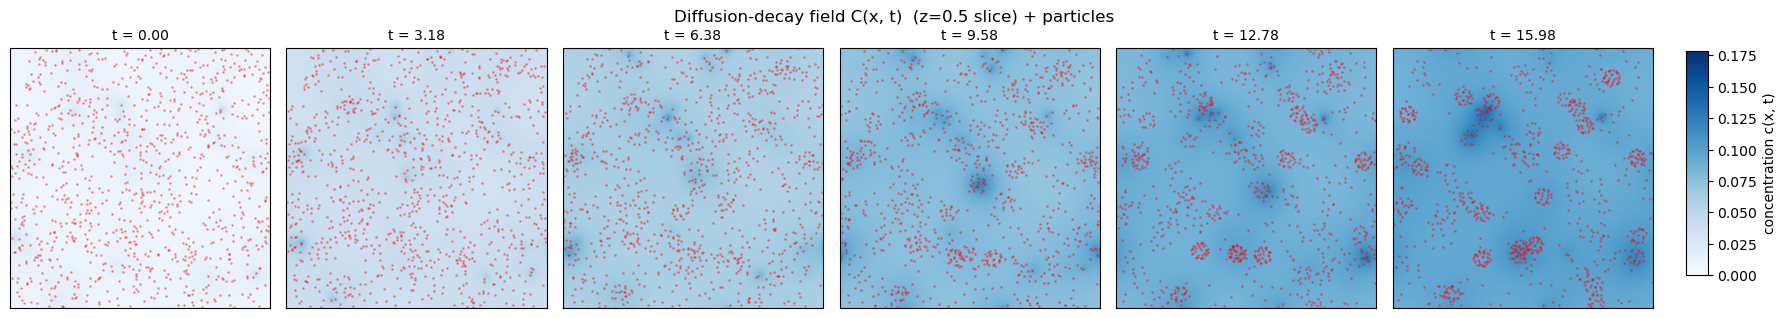

In [8]:
# Show field slices at 6 evenly spaced snapshots
preview_indices = np.linspace(0, n_snapshots - 1, 6, dtype=int)
vmax_preview = field_grid_history.max()

fig, axes = plt.subplots(1, len(preview_indices), figsize=(3 * len(preview_indices), 3.2))
for i, idx in enumerate(preview_indices):
    ax = axes[i]
    img = field_grid_history[idx]
    im = ax.imshow(img, extent=[0, 1, 0, 1], origin='lower',
                   cmap='Blues', vmin=0, vmax=vmax_preview)
    # overlay particle xy positions
    pos = pos_history[idx]
    ax.scatter(pos[:, 0], pos[:, 1], s=1, c='red', alpha=0.3)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
    ax.set_title(f't = {time_history[idx]:.2f}', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Diffusion-decay field C(x, t)  (z=0.5 slice) + particles', fontsize=12)
plt.tight_layout(rect=[0, 0, 0.93, 1])
cbar_ax = fig.add_axes([0.94, 0.15, 0.012, 0.7])
fig.colorbar(im, cax=cbar_ax, label='concentration c(x, t)')
plt.show()

## Generate video

In [9]:
out_dir = Path('../tmp_training/diffusion_field_test')
out_dir.mkdir(parents=True, exist_ok=True)

vmax_field = field_grid_history.max()
vmax_particle = field_history.max()

fig = plt.figure(figsize=(18, 6))

# panel 1: 3D scatter
ax1 = fig.add_subplot(131, projection='3d')
# panel 2: top-down particles
ax2 = fig.add_subplot(132)
# panel 3: top-down field + particles
ax3 = fig.add_subplot(133)

# Persistent colorbar for the field panel
_seed_img = ax3.imshow(np.zeros_like(field_grid_history[0]), extent=[0, 1, 0, 1],
                        origin='lower', cmap='Blues', vmin=0, vmax=vmax_field)
cbar = fig.colorbar(_seed_img, ax=ax3, fraction=0.046, pad=0.04,
                    label='concentration c(x, t)')


def update(frame_idx):
    pos = pos_history[frame_idx]
    t = time_history[frame_idx]
    fvals = field_history[frame_idx]
    field_img = field_grid_history[frame_idx]

    # --- Panel 1: 3D ---
    ax1.cla()
    ax1.scatter(pos[:, 0], pos[:, 1], pos[:, 2], s=3, c=fvals, cmap='YlOrRd',
               vmin=0, vmax=vmax_particle, alpha=0.7)
    ax1.set_xlim(0, 1); ax1.set_ylim(0, 1); ax1.set_zlim(0, 1)
    ax1.set_box_aspect([1, 1, 1])
    ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')
    ax1.set_title(f'3D  t={t:.3f}')

    # --- Panel 2: top-down xy ---
    ax2.cla()
    ax2.scatter(pos[:, 0], pos[:, 1], s=3, c=fvals, cmap='YlOrRd',
               vmin=0, vmax=vmax_particle, alpha=0.7)
    ax2.set_xlim(0, 1); ax2.set_ylim(0, 1); ax2.set_aspect('equal')
    ax2.set_xlabel('x'); ax2.set_ylabel('y')
    ax2.set_title('Top-down particles')

    # --- Panel 3: field slice + particles ---
    ax3.cla()
    ax3.imshow(field_img, extent=[0, 1, 0, 1], origin='lower',
               cmap='Blues', vmin=0, vmax=vmax_field, alpha=0.8)
    ax3.scatter(pos[:, 0], pos[:, 1], s=3, c='red', alpha=0.5)
    ax3.set_xlim(0, 1); ax3.set_ylim(0, 1); ax3.set_aspect('equal')
    ax3.set_xlabel('x'); ax3.set_ylabel('y')
    ax3.set_title('Field (z=0.5) + particles')

    fig.suptitle(f'Frame {frame_idx}/{n_snapshots}  t={t:.3f}', fontsize=14)


print('Rendering video...')
ani = animation.FuncAnimation(fig, update, frames=n_snapshots, interval=50)
video_path = str(out_dir / 'diffusion_field_test.mp4')
ani.save(video_path, writer='ffmpeg', fps=30, dpi=100)
plt.close(fig)
print(f'Saved: {video_path}')

Rendering video...
Saved: ../tmp_training/diffusion_field_test/diffusion_field_test.mp4


In [10]:
display(Video(video_path, embed=True, width=900))

## Static snapshots (first, middle, last)

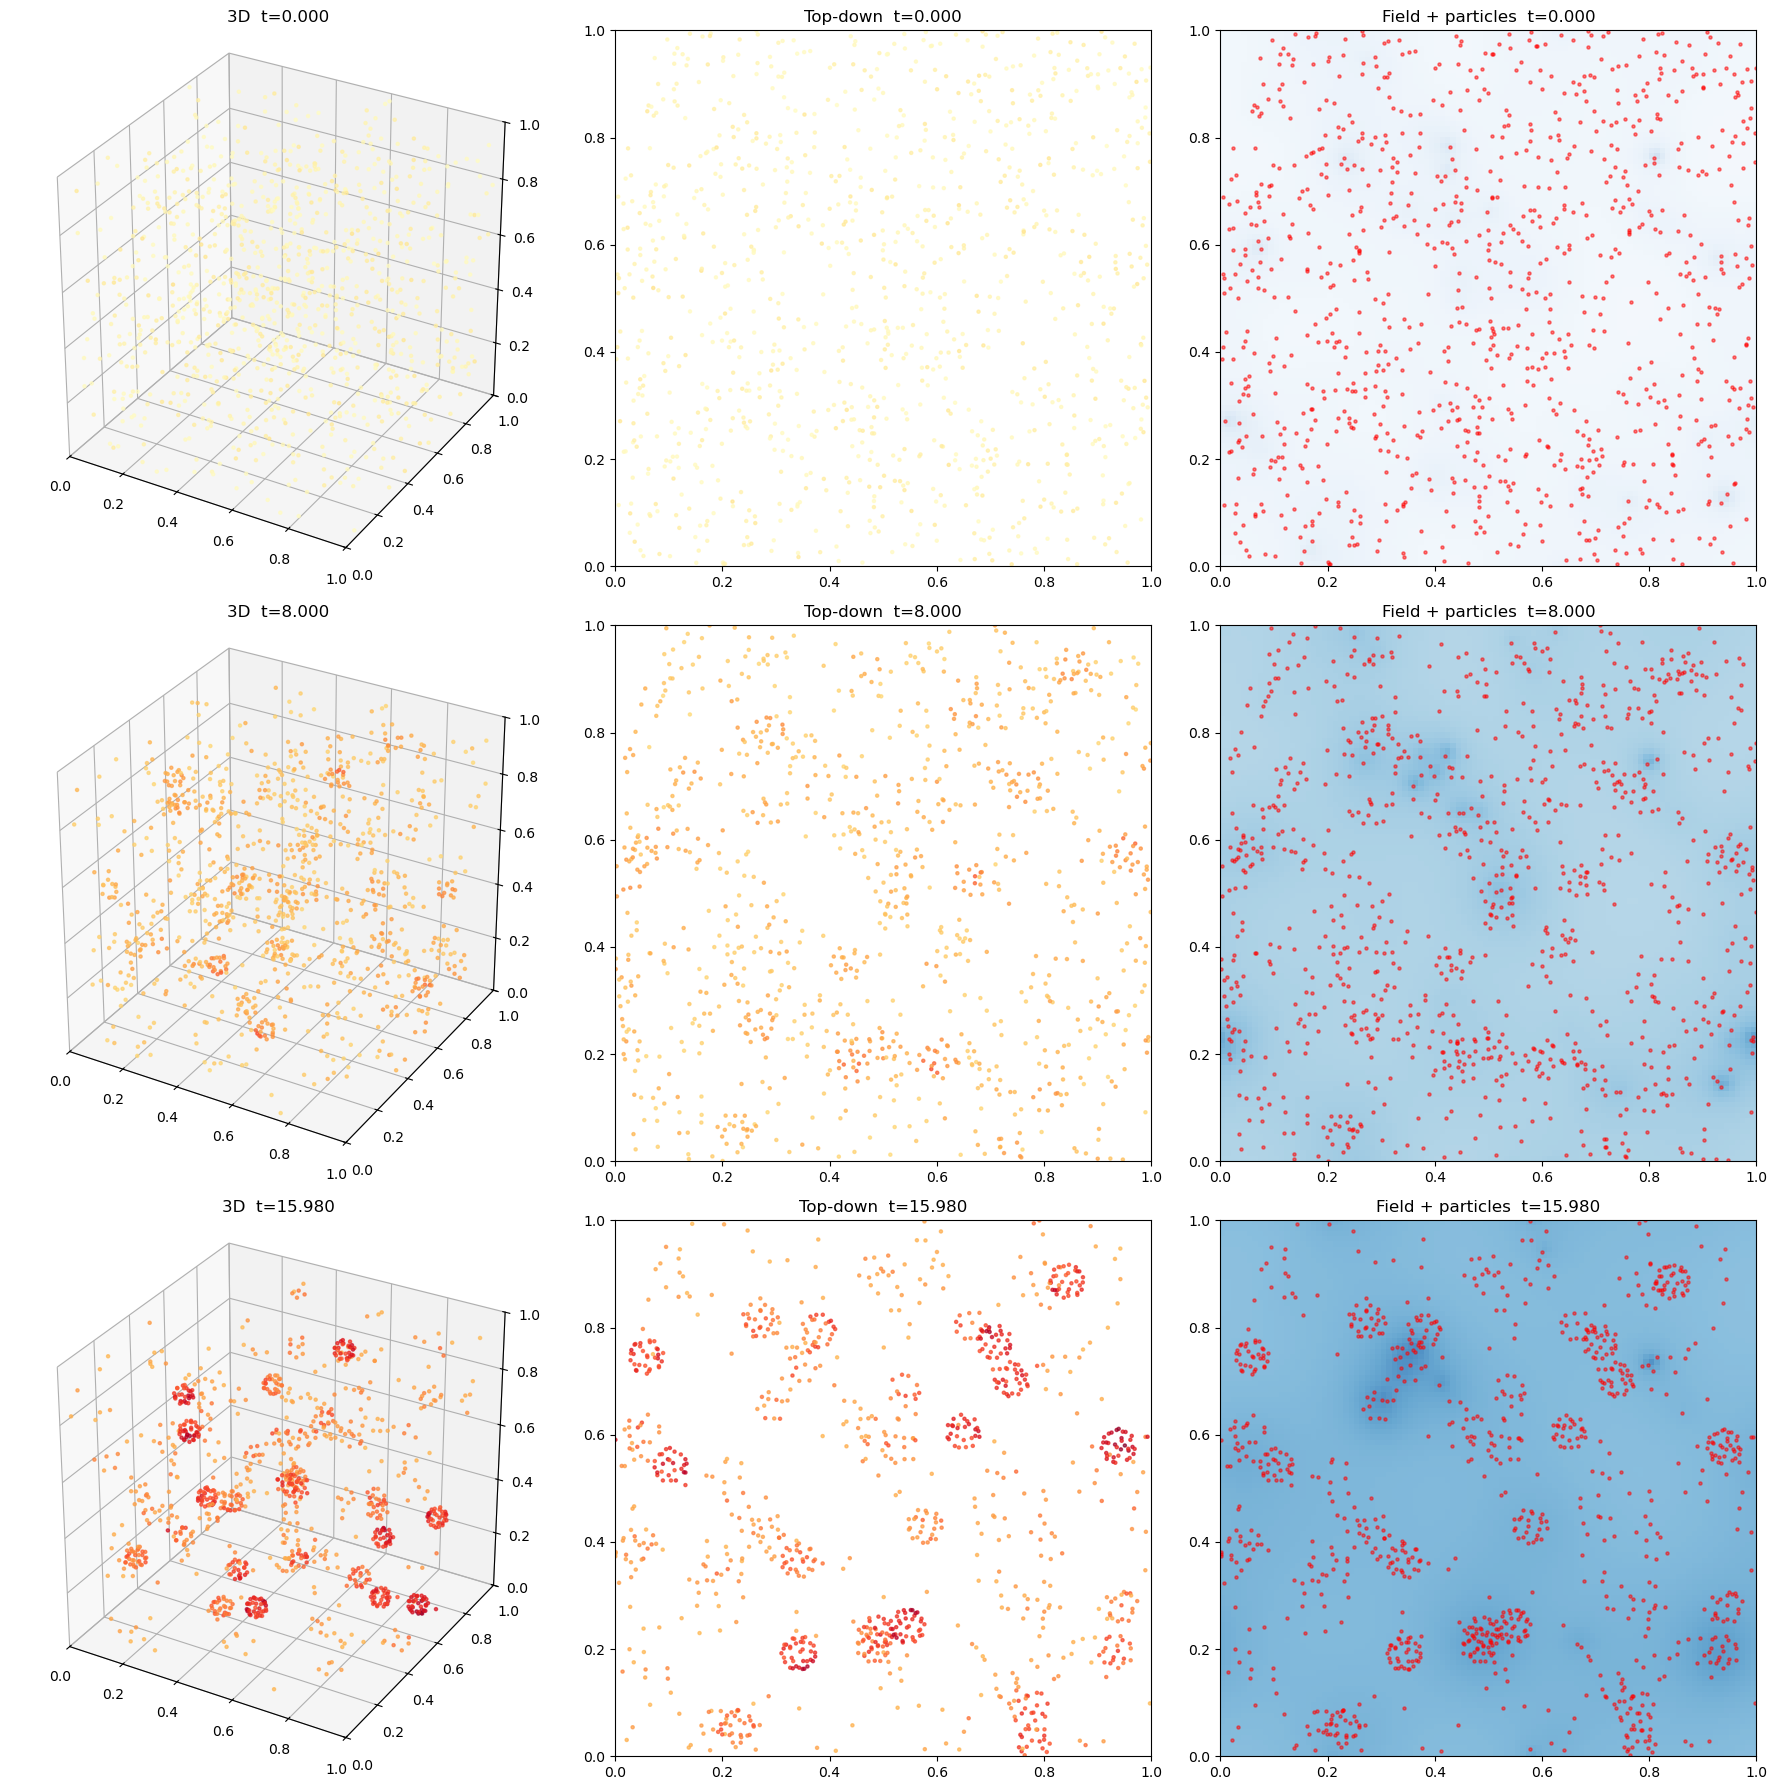

Saved snapshots to ../tmp_training/diffusion_field_test/snapshots.png


In [11]:
snap_indices = [0, n_snapshots // 2, n_snapshots - 1]

fig, axes = plt.subplots(len(snap_indices), 3, figsize=(18, 6 * len(snap_indices)))

for row, idx in enumerate(snap_indices):
    pos = pos_history[idx]
    t = time_history[idx]
    fvals = field_history[idx]
    field_img = field_grid_history[idx]

    # 3D
    ax = fig.add_subplot(len(snap_indices), 3, row * 3 + 1, projection='3d')
    ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2], s=5, c=fvals, cmap='YlOrRd',
              vmin=0, vmax=vmax_particle, alpha=0.7)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_zlim(0, 1)
    ax.set_box_aspect([1, 1, 1])
    ax.set_title(f'3D  t={t:.3f}')

    # top-down particles
    ax2 = axes[row, 1]
    ax2.scatter(pos[:, 0], pos[:, 1], s=5, c=fvals, cmap='YlOrRd',
               vmin=0, vmax=vmax_particle, alpha=0.7)
    ax2.set_xlim(0, 1); ax2.set_ylim(0, 1); ax2.set_aspect('equal')
    ax2.set_title(f'Top-down  t={t:.3f}')

    # field + particles
    ax3 = axes[row, 2]
    ax3.imshow(field_img, extent=[0, 1, 0, 1], origin='lower',
              cmap='Blues', vmin=0, vmax=vmax_field, alpha=0.8)
    ax3.scatter(pos[:, 0], pos[:, 1], s=5, c='red', alpha=0.5)
    ax3.set_xlim(0, 1); ax3.set_ylim(0, 1); ax3.set_aspect('equal')
    ax3.set_title(f'Field + particles  t={t:.3f}')

    # hide the axes[row, 0] since we replaced it with 3D projection
    axes[row, 0].set_visible(False)

fig.tight_layout()
fig.savefig(str(out_dir / 'snapshots.png'), dpi=150)
plt.show()
print(f'Saved snapshots to {out_dir / "snapshots.png"}')